# CFLOW Two-Stage (Severstal, Colab)

This notebook builds a two-stage pipeline using:
- Stage 1: CFLOW-repo-based feature extractor + anomaly scoring against normal embeddings
- Stage 2: ResNet50 known-class classifier

Final outputs include stage-1 metrics and integrated two-stage metrics on `normal_test`, `known_test`, and `unknown_test`.


In [1]:
"""import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "numpy==1.26.4"])
print("Installed numpy 1.26.4. Restart runtime now.")"""

'import sys, subprocess\nsubprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "numpy==1.26.4"])\nprint("Installed numpy 1.26.4. Restart runtime now.")'

In [2]:
# 1) Runtime preflight
import sys
import numpy as np
import torch
import torchvision

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Torch:', torch.__version__)
print('TorchVision:', torchvision.__version__)

if not np.__version__.startswith('1.26'):
    raise RuntimeError('Need numpy==1.26.x. Install numpy==1.26.4, restart runtime, rerun notebook.')

print('Preflight OK')


Python: 3.12.12
NumPy: 1.26.4
Torch: 2.10.0+cu128
TorchVision: 0.25.0+cu128
Preflight OK


In [3]:
# 2) Setup repos + deps
import os
import sys
import subprocess
from pathlib import Path

REPO = Path('/content/FYP-code')
if not REPO.exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/spinelessknave8/FYP_code.git', str(REPO)])
subprocess.check_call(['git', '-C', str(REPO), 'fetch', 'origin'])
subprocess.check_call(['git', '-C', str(REPO), 'reset', '--hard', 'origin/main'])

CFLOW_REPO = Path('/content/cflow-ad')
if not CFLOW_REPO.exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/gudovskiy/cflow-ad', str(CFLOW_REPO)])

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm==0.9.7', 'FrEIA==0.2', 'scikit-learn==1.3.2'])

os.chdir(REPO)
for p in [str(REPO), str(REPO/'severstral-osr'/'src'), str(REPO/'src'), str(CFLOW_REPO), str(CFLOW_REPO/'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

print('Repos ready')


Repos ready


In [4]:
# 3) Drive + dataset checks
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

DATA_ROOT = Path('/content/drive/MyDrive/datasets/severstal')
TRAIN_CSV = DATA_ROOT / 'train.csv'
TRAIN_IMAGES = DATA_ROOT / 'train_images'
OUT_ROOT = Path('/content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage')
OUT_ROOT.mkdir(parents=True, exist_ok=True)

assert TRAIN_CSV.exists(), f'Missing: {TRAIN_CSV}'
assert TRAIN_IMAGES.exists() and TRAIN_IMAGES.is_dir(), f'Missing: {TRAIN_IMAGES}'

print('DATA_ROOT:', DATA_ROOT)
print('OUT_ROOT :', OUT_ROOT)


Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/datasets/severstal
OUT_ROOT : /content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage


In [5]:
# 4) Build split (normal / known / unknown)
import csv
import json
import random
from collections import defaultdict

SEED = 42
rng = random.Random(SEED)
KNOWN_CLASSES = ['Class_1', 'Class_2', 'Class_3']

rows_by_image = defaultdict(list)
with open(TRAIN_CSV, 'r', newline='') as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows_by_image[r['ImageId'].strip()].append(r)

all_images = [p for p in TRAIN_IMAGES.iterdir() if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]

# normal images = no positive mask rows
normal_paths = []
single_label_defects = []  # (path, Class_k)

for p in all_images:
    img_id = p.name
    img_rows = rows_by_image.get(img_id, [])
    pos_classes = set()
    for r in img_rows:
        enc = str(r.get('EncodedPixels', '')).strip().lower()
        if enc and enc != 'nan':
            pos_classes.add(int(r['ClassId']))
    if len(pos_classes) == 0:
        normal_paths.append(str(p))
    elif len(pos_classes) == 1:
        cls = next(iter(pos_classes))
        single_label_defects.append((str(p), f'Class_{cls}'))

known_all = [(p,c) for p,c in single_label_defects if c in KNOWN_CLASSES]
unknown_all = [(p,c) for p,c in single_label_defects if c not in KNOWN_CLASSES]

if len(known_all) == 0 or len(unknown_all) == 0:
    raise RuntimeError('Known/unknown split empty; verify Severstal classes and train.csv parsing.')

# stratified split for known classes
def stratified_split(samples, train_ratio=0.7, val_ratio=0.15, seed=42):
    rr = random.Random(seed)
    by_cls = defaultdict(list)
    for s in samples:
        by_cls[s[1]].append(s)
    tr, va, te = [], [], []
    for _, items in by_cls.items():
        rr.shuffle(items)
        n = len(items)
        ntr = int(n*train_ratio)
        nva = int(n*val_ratio)
        tr += items[:ntr]
        va += items[ntr:ntr+nva]
        te += items[ntr+nva:]
    return tr, va, te

known_train, known_val, known_test = stratified_split(known_all, seed=SEED)
rng.shuffle(normal_paths)
rng.shuffle(unknown_all)

# pilot caps
MAX_NORMAL_TRAIN = 1200
MAX_NORMAL_VAL = 300
MAX_NORMAL_TEST = 300
MAX_KNOWN_TRAIN = 900
MAX_KNOWN_VAL = 300
MAX_KNOWN_TEST = 300
MAX_UNKNOWN_TEST = 300

normal_train = normal_paths[:MAX_NORMAL_TRAIN]
normal_val = normal_paths[MAX_NORMAL_TRAIN:MAX_NORMAL_TRAIN+MAX_NORMAL_VAL]
normal_test = normal_paths[MAX_NORMAL_TRAIN+MAX_NORMAL_VAL:MAX_NORMAL_TRAIN+MAX_NORMAL_VAL+MAX_NORMAL_TEST]

known_train = known_train[:MAX_KNOWN_TRAIN]
known_val = known_val[:MAX_KNOWN_VAL]
known_test = known_test[:MAX_KNOWN_TEST]
unknown_test = unknown_all[:MAX_UNKNOWN_TEST]

if min(len(normal_train), len(normal_val), len(normal_test), len(known_train), len(known_test), len(unknown_test)) == 0:
    raise RuntimeError('Split contains an empty partition.')

split = {
    'seed': SEED,
    'known_classes': KNOWN_CLASSES,
    'normal_train': normal_train,
    'normal_val': normal_val,
    'normal_test': normal_test,
    'known_train': known_train,
    'known_val': known_val,
    'known_test': known_test,
    'unknown_test': unknown_test,
}

split_path = OUT_ROOT / 'split_manifest.json'
split_path.write_text(json.dumps(split, indent=2))
print('Saved split:', split_path)
print({
    'normal_train':len(normal_train),
    'normal_val':len(normal_val),
    'normal_test':len(normal_test),
    'known_train':len(known_train),
    'known_val':len(known_val),
    'known_test':len(known_test),
    'unknown_test':len(unknown_test),
})


Saved split: /content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage/split_manifest.json
{'normal_train': 1200, 'normal_val': 300, 'normal_test': 300, 'known_train': 900, 'known_val': 300, 'known_test': 300, 'unknown_test': 300}


In [7]:
# 5) Stage 1 (STRICT): official CFLOW loader sanity check on tiny sample
import json
import time
import numpy as np
import torch
from types import SimpleNamespace
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.neighbors import NearestNeighbors

split = json.loads((OUT_ROOT / 'split_manifest.json').read_text())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Strict official import: must exist, otherwise fail.
try:
    import model as cflow_model
except Exception as e:
    raise RuntimeError('CFLOW official import failed: expected /content/cflow-ad/model.py import as `model`.') from e

if not hasattr(cflow_model, 'load_encoder_arch'):
    raise RuntimeError('CFLOW official loader missing: `load_encoder_arch` not found in cflow model module.')

# Build config object expected by CFLOW loader.
c = SimpleNamespace(enc_arch='wide_resnet50_2')
try:
    enc_obj = cflow_model.load_encoder_arch(c, 3)
except Exception as e:
    raise RuntimeError('CFLOW official loader call failed. Expected signature like load_encoder_arch(config_obj, 3).') from e

encoder = enc_obj[0] if isinstance(enc_obj, (tuple, list)) else enc_obj
if not hasattr(encoder, 'to'):
    raise RuntimeError('CFLOW loader returned non-model object; cannot run encoder forward pass.')
encoder = encoder.to(device).eval()

# Strict transforms kept consistent across stage1.
tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class PathDS(Dataset):
    def __init__(self, rows, with_label=False):
        self.rows = rows
        self.with_label = with_label
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        row = self.rows[i]
        if self.with_label:
            path, label = row
        else:
            path, label = row, -1   # NOT None
        x = tf(Image.open(path).convert('RGB'))
        return x, label

def embed(rows, with_label=False, bs=16):
    dl = DataLoader(PathDS(rows, with_label=with_label), batch_size=bs, shuffle=False, num_workers=2)
    feats, labels = [], []
    for x, y in dl:
        x = x.to(device)
        z = forward_feats(x)
        feats.append(z.detach().cpu().numpy())
        if with_label:
            labels.extend(list(y))
    return np.concatenate(feats, axis=0), labels

def forward_feats(x):
    with torch.no_grad():
        out = encoder(x)
    feat = out[-1] if isinstance(out, (list, tuple)) else out
    if not isinstance(feat, torch.Tensor):
        raise RuntimeError('CFLOW encoder forward output is not a tensor/list of tensors.')
    if feat.ndim == 4:
        feat = feat.mean(dim=(2, 3))
    if feat.ndim != 2:
        raise RuntimeError(f'Expected 2D embeddings after pooling; got shape {tuple(feat.shape)}')
    return feat

# Tiny sanity split first (fast fail)
SANITY = {
    'normal_train': split['normal_train'][:64],
    'normal_val': split['normal_val'][:32],
    'normal_test': split['normal_test'][:32],
    'known_test': split['known_test'][:32],
    'unknown_test': split['unknown_test'][:32],
}
if min(len(SANITY['normal_train']), len(SANITY['normal_val']), len(SANITY['normal_test']), len(SANITY['known_test']), len(SANITY['unknown_test'])) == 0:
    raise RuntimeError('Sanity split too small/empty; check split_manifest sizes.')

start = time.time()
E_ntr_s, _ = embed(SANITY['normal_train'])
E_nva_s, _ = embed(SANITY['normal_val'])
E_nts_s, _ = embed(SANITY['normal_test'])
E_kts_s, _ = embed(SANITY['known_test'], with_label=True)
E_uts_s, _ = embed(SANITY['unknown_test'], with_label=True)

knn_s = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(E_ntr_s)
score_s = lambda E: knn_s.kneighbors(E, return_distance=True)[0].mean(axis=1)
_ = score_s(E_nva_s), score_s(E_nts_s), score_s(E_kts_s), score_s(E_uts_s)

print('CFLOW official loader sanity pass.')
print('Embedding dim:', E_ntr_s.shape[1], 'sanity elapsed: %.1fs' % (time.time()-start))

# Store validated encoder reference metadata
(OUT_ROOT / 'stage1_impl.txt').write_text('official_cflow_model_load_encoder_arch\n')


CFLOW official loader sanity pass.
Embedding dim: 2048 sanity elapsed: 50.9s


39

In [8]:
# 6) Stage 1 full scoring (STRICT official CFLOW only)
import json
import time
import numpy as np
import torch
from types import SimpleNamespace
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.neighbors import NearestNeighbors

split = json.loads((OUT_ROOT / 'split_manifest.json').read_text())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import model as cflow_model
c = SimpleNamespace(enc_arch='wide_resnet50_2')
enc_obj = cflow_model.load_encoder_arch(c, 3)
encoder = enc_obj[0] if isinstance(enc_obj, (tuple, list)) else enc_obj
encoder = encoder.to(device).eval()

tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class PathDS(Dataset):
    def __init__(self, rows, with_label=False):
        self.rows = rows
        self.with_label = with_label
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        row = self.rows[i]
        if self.with_label:
            path, label = row
        else:
            path, label = row, -1   # NOT None
        x = tf(Image.open(path).convert('RGB'))
        return x, label

def embed(rows, with_label=False, bs=16):
    dl = DataLoader(PathDS(rows, with_label=with_label), batch_size=bs, shuffle=False, num_workers=2)
    feats, labels = [], []
    for x, y in dl:
        x = x.to(device)
        z = forward_feats(x)
        feats.append(z.detach().cpu().numpy())
        if with_label:
            labels.extend(list(y))
    return np.concatenate(feats, axis=0), labels

def forward_feats(x):
    with torch.no_grad():
        out = encoder(x)
    feat = out[-1] if isinstance(out, (list, tuple)) else out
    if feat.ndim == 4:
        feat = feat.mean(dim=(2, 3))
    return feat

start = time.time()
E_ntr, _ = embed(split['normal_train'])
E_nva, _ = embed(split['normal_val'])
E_nts, _ = embed(split['normal_test'])
E_kts, y_kts = embed(split['known_test'], with_label=True)
E_uts, y_uts = embed(split['unknown_test'], with_label=True)

knn = NearestNeighbors(n_neighbors=5, metric='euclidean').fit(E_ntr)
score = lambda E: knn.kneighbors(E, return_distance=True)[0].mean(axis=1)

s_nva = score(E_nva)
s_nts = score(E_nts)
s_kts = score(E_kts)
s_uts = score(E_uts)

np.save(OUT_ROOT / 'stage1_scores_normal_val.npy', s_nva)
np.save(OUT_ROOT / 'stage1_scores_normal_test.npy', s_nts)
np.save(OUT_ROOT / 'stage1_scores_known_test.npy', s_kts)
np.save(OUT_ROOT / 'stage1_scores_unknown_test.npy', s_uts)
np.savez(OUT_ROOT / 'stage1_embeddings_test.npz', known=E_kts, unknown=E_uts)

print('Stage1 full scoring done in %.1fs' % (time.time()-start))



Stage1 full scoring done in 793.4s


In [9]:
# 7) Stage 2: train known-class ResNet50 classifier
import json
import time
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from src.models.resnet50 import build_resnet50

split = json.loads((OUT_ROOT / 'split_manifest.json').read_text())
known_classes = split['known_classes']
class_to_idx = {c:i for i,c in enumerate(known_classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class KnownDS(Dataset):
    def __init__(self, rows):
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        p, c = self.rows[i]
        x = tf(Image.open(p).convert('RGB'))
        y = class_to_idx[c]
        return x, y

tr_dl = DataLoader(KnownDS(split['known_train']), batch_size=32, shuffle=True, num_workers=2)
va_dl = DataLoader(KnownDS(split['known_val']), batch_size=32, shuffle=False, num_workers=2)
te_dl = DataLoader(KnownDS(split['known_test']), batch_size=32, shuffle=False, num_workers=2)

model = build_resnet50(num_classes=len(known_classes), pretrained=True).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

best_va = -1.0
best_state = None
EPOCHS = 4
start = time.time()

for ep in range(EPOCHS):
    model.train()
    for x,y in tr_dl:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = crit(logits,y)
        loss.backward()
        opt.step()

    model.eval()
    cor = 0
    tot = 0
    with torch.no_grad():
        for x,y in va_dl:
            x,y = x.to(device), y.to(device)
            pr = model(x).argmax(dim=1)
            cor += (pr==y).sum().item()
            tot += len(y)
    va_acc = cor / max(1,tot)
    print(f'epoch {ep+1}/{EPOCHS} val_acc={va_acc:.4f}')
    if va_acc > best_va:
        best_va = va_acc
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}

model.load_state_dict(best_state)

# test logits for known/unknown sets
def logits_for_rows(rows):
    class RowsDS(Dataset):
        def __init__(self, rows): self.rows = rows
        def __len__(self): return len(self.rows)
        def __getitem__(self, i):
            row = self.rows[i]
            if isinstance(row, (tuple, list)):
                p = row[0]
            else:
                p = row
            x = tf(Image.open(p).convert('RGB'))
            return x
    dl = DataLoader(RowsDS(rows), batch_size=32, shuffle=False, num_workers=2)
    out=[]
    model.eval()
    with torch.no_grad():
        for x in dl:
            x=x.to(device)
            out.append(model(x).cpu().numpy())
    return np.concatenate(out, axis=0)

log_known_val = logits_for_rows(split['known_val'])
log_known = logits_for_rows(split['known_test'])
log_unknown = logits_for_rows(split['unknown_test'])

np.save(OUT_ROOT / 'stage2_logits_known_val.npy', log_known_val)
np.save(OUT_ROOT / 'stage2_logits_known_test.npy', log_known)
np.save(OUT_ROOT / 'stage2_logits_unknown_test.npy', log_unknown)

# known-test accuracy
y_known_true = np.array([class_to_idx[c] for _,c in split['known_test']])
y_known_pred = log_known.argmax(axis=1)
known_acc = float((y_known_pred==y_known_true).mean())

print('Stage2 done in %.1fs' % (time.time()-start))
print('Stage2 known_test_accuracy:', round(known_acc,4))


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


epoch 1/4 val_acc=1.0000
epoch 2/4 val_acc=1.0000
epoch 3/4 val_acc=1.0000
epoch 4/4 val_acc=1.0000
Stage2 done in 465.3s
Stage2 known_test_accuracy: 1.0


In [10]:
# 8) Integrated two-stage metrics (recalibrated stage2 margin gating)
import json
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

split = json.loads((OUT_ROOT / 'split_manifest.json').read_text())
known_classes = split['known_classes']
class_to_idx = {c:i for i,c in enumerate(known_classes)}

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=1, keepdims=True)

def top1_top2_margin(logits):
    # Larger margin => more in-distribution confidence.
    part = np.partition(logits, -2, axis=1)
    top2 = part[:, -2]
    top1 = part[:, -1]
    return top1 - top2

s_nva = np.load(OUT_ROOT / 'stage1_scores_normal_val.npy')
s_nts = np.load(OUT_ROOT / 'stage1_scores_normal_test.npy')
s_kts = np.load(OUT_ROOT / 'stage1_scores_known_test.npy')
s_uts = np.load(OUT_ROOT / 'stage1_scores_unknown_test.npy')

log_known_val = np.load(OUT_ROOT / 'stage2_logits_known_val.npy')
log_known = np.load(OUT_ROOT / 'stage2_logits_known_test.npy')
log_unknown = np.load(OUT_ROOT / 'stage2_logits_unknown_test.npy')

margin_known_val = top1_top2_margin(log_known_val)
margin_known = top1_top2_margin(log_known)
margin_unknown = top1_top2_margin(log_unknown)

pred_known = log_known.argmax(axis=1)
y_known_true = np.array([class_to_idx[c] for _,c in split['known_test']])

# stage1 detection AUROC (normal vs all defects)
y_det = np.concatenate([np.zeros(len(s_nts)), np.ones(len(s_kts)+len(s_uts))])
s_det = np.concatenate([s_nts, s_kts, s_uts])
auroc_det = float(roc_auc_score(y_det, s_det))

rows=[]
for fpr in [0.05, 0.10, 0.20]:
    tau = float(np.quantile(s_nva, 1.0-fpr))

    # Recalibrated stage2 threshold: margin quantile on known validation only.
    # lower margin => unknown; so choose lower-quantile as kappa.
    kappa_margin = float(np.quantile(margin_known_val, fpr))

    # stage1 decision
    n_as_def = s_nts > tau
    k_as_def = s_kts > tau
    u_as_def = s_uts > tau

    # stage2 known vs unknown decision among stage1 positives
    k_is_unknown = margin_known < kappa_margin
    u_is_unknown = margin_unknown < kappa_margin

    # integrated success definitions
    k_success = k_as_def & (~k_is_unknown) & (pred_known == y_known_true)
    u_success = u_as_def & u_is_unknown

    rows.append({
        'fpr_target': fpr,
        'tau_stage1': tau,
        'kappa_stage2_margin': kappa_margin,
        'AUROC_defect_screening': auroc_det,
        'TPR_defect@FPR': float(np.mean(np.concatenate([k_as_def, u_as_def]))),
        'TPR_unknown@FPR': float(np.mean(u_as_def)),
        'FPR_known_as_def@FPR': float(np.mean(k_as_def)),
        'FPR_normal_realized': float(np.mean(n_as_def)),
        'known_classification_acc_given_stage1': float(np.mean((pred_known == y_known_true)[k_as_def])) if np.any(k_as_def) else float('nan'),
        'two_stage_known_success': float(np.mean(k_success)),
        'two_stage_unknown_success': float(np.mean(u_success)),
        'stage2_unknown_rate_known_all': float(np.mean(k_is_unknown)),
        'stage2_unknown_rate_unknown_all': float(np.mean(u_is_unknown)),
    })

res = pd.DataFrame(rows)
res_path = OUT_ROOT / 'cflow_two_stage_summary.csv'
res.to_csv(res_path, index=False)
print('Saved:', res_path)
display(res)


Saved: /content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage/cflow_two_stage_summary.csv


,fpr_target,tau_stage1,kappa_stage2,AUROC_defect_screening,TPR_defect@FPR,TPR_unknown@FPR,FPR_known_as_def@FPR,FPR_normal_realized,known_classification_acc_given_stage1,two_stage_known_success,two_stage_unknown_success
0,0.05,16.949301,0.999915,0.845694,0.335000,0.420000,0.250000,0.043333,1.0,0.250000,0.016667
1,0.10,14.900338,0.999965,0.845694,0.533333,0.653333,0.413333,0.103333,1.0,0.383333,0.050000
2,0.20,12.848346,0.999992,0.845694,0.745000,0.883333,0.606667,0.230000,1.0,0.510000,0.123333


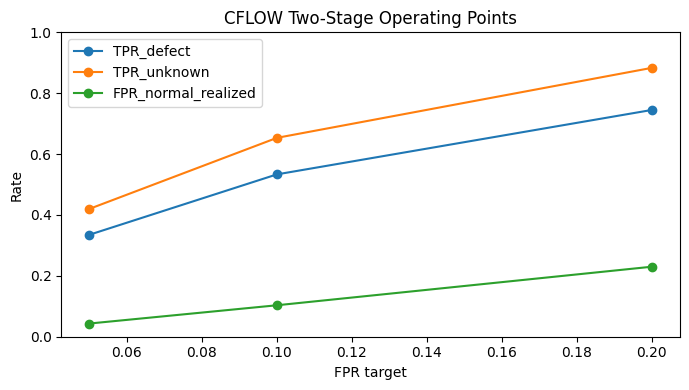

Saved: /content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage/plot_cflow_two_stage_rates.png


In [11]:
# 9) Quick plots
import pandas as pd
import matplotlib.pyplot as plt

res = pd.read_csv(OUT_ROOT / 'cflow_two_stage_summary.csv')

plt.figure(figsize=(7,4))
plt.plot(res['fpr_target'], res['TPR_defect@FPR'], marker='o', label='TPR_defect')
plt.plot(res['fpr_target'], res['TPR_unknown@FPR'], marker='o', label='TPR_unknown')
plt.plot(res['fpr_target'], res['FPR_normal_realized'], marker='o', label='FPR_normal_realized')
plt.xlabel('FPR target')
plt.ylabel('Rate')
plt.ylim(0,1)
plt.legend()
plt.title('CFLOW Two-Stage Operating Points')
plt.tight_layout()
plot1 = OUT_ROOT / 'plot_cflow_two_stage_rates.png'
plt.savefig(plot1, dpi=140)
plt.show()

print('Saved:', plot1)


## 10) Rerun after disconnect

1. Ensure `numpy==1.26.4`, restart runtime if changed.
2. Run all cells top-to-bottom.
3. Outputs are written to:
`/content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage/`
